# Bayesians vs. Frequentists

The Bayesian approach is a different way to look at statistical inference than what is typically taught in STATS101 classes. The latter is known as frequentist or classical statistics and is quite different from the Bayesian approach.

Let's see if you recognize the differences between these two worlds!

<center><img src="images/01.01.png"  style="width: 400px, height: 300px;"/></center>

# Probability distributions

 Now you have the general idea of what the Bayesian approach is all about. Among other things, you know that for a Bayesian, parameters of statistical models are random variables which can be described by probability distributions.

This exercise will test your ability to visualize and interpret probability distributions. You have been given a long list of draws from a distribution of the heights of plants in centimeters, contained in the variable draws. 

Draws: [-0.28110029  1.79768653  0.64084286 -0.57117899  0.57258278]
Length of draws: 1000


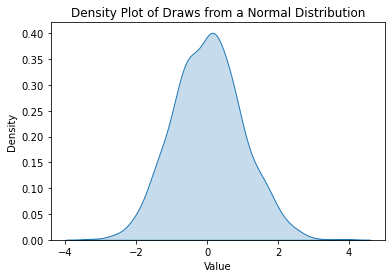

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
np.random.seed(42)

# Generate 1000 random draws from a normal distribution
mean = 0
std_dev = 1
num_draws = 1000
draws = np.random.normal(loc=mean, scale=std_dev, size=num_draws)

# Print the list of draws
print("Draws:", draws[-5:])

# Print the length of draws
print("Length of draws:", len(draws)) # 1000

# Plot the density of draws
sns.kdeplot(draws, shade=True)
plt.title('Density Plot of Draws from a Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.show()


# Let's play cards

You have a regular deck of 52 well-shuffled playing cards. The deck consists of 4 suits, and there are 13 cards in each suite: ranks 2 through 10, a jack, a queen, a king, and an ace. This means that in the whole deck of 52, there are four of each distinct rank: four aces, four kings, four tens, four fives, etc.

Since there are 52 distinct cards, the probability of drawing any one particular card is 1/52. Using the two rules of probability you've learned about in the last video, calculate the probabilities of drawing some specific combinations of cards, as described in the instructions.

In [3]:
# Calculate probability of drawing a king or queen
p_king_or_queen = 4/52 + 4/52
print(p_king_or_queen)

0.15384615384615385


In [4]:
# Calculate probability of drawing <= 5
p_five_or_less = 4 * 4/52 # Since there are 2,3,4,5 numbered cards and each has equally likelihood
print(p_five_or_less)

0.3076923076923077


In [7]:
# Calculate probability of drawing four aces in a row
p_all_four_aces = 1/52  * 1/51 * 1/50 * 1/49
print(p_all_four_aces)

1.5390771693292702e-07


# Bayesian spam filter

et's now tackle the famous Bayes' Theorem and use it for a simple but important task: spam detection.

While browsing your inbox, you have figured out that quite a few of the emails you would rather not waste your time on reading contain exclamatory statements, such as "BUY NOW!!!". You start thinking that the presence of three exclamation marks next to each other might be a good spam predictor! Hence you've prepared a DataFrame called emails with two variables: spam, whether the email was spam, and contains_3_exlc, whether it contains the string "!!!". The head of the data looks like this:
```
     spam    contains_3_excl
0    False             False
1    False             False
2    True              False
3    False             False
4    False             False
```
Your job is to calculate the probability of the email being spam given that it contains three exclamation marks. Let's tackle it step by step! Here is Bayes' formula for your reference:

In [8]:
# # Calculate and print the unconditional probability of spam
# p_spam = emails["spam"].mean()
# print(p_spam)

# # Calculate and print the unconditional probability of "!!!"
# p_3_excl = emails["contains_3_excl"].mean()
# print(p_3_excl)

# # Calculate and print the probability of "!!!" given spam
# p_3_excl_given_spam = emails.loc[emails["spam"]]["contains_3_excl"].mean()
# print(p_3_excl_given_spam)

# # Calculate and print the probability of spam given "!!!"
# p_spam_given_3_excl = p_3_excl_given_spam * p_spam/p_3_excl
# print(p_spam_given_3_excl)

# What does the test say?

A doctor suspects a disease in their patient, so they run a medical test. The test's manufacturer claims that 99% of sick patients test positive, while the doctor has observed that the test comes back positive in 2% of all cases. The suspected disease is quite rare: only 1 in 1000 people suffer from it.

The test result came back positive. What is the probability that the patient is indeed sick?

In [9]:
p_sick = 1/1000
p_positive = .02
p_positive_sick = 0.99
p_sick_positive = p_positive_sick * p_sick/p_positive
p_sick_positive

0.049499999999999995

# Tossing a coin

Watch out for the confusion: there are two different probability distributions involved! One is the binomial, which we use to model the coin-flipping. It's a discrete distribution with two possible values (heads or tails) parametrized with the probability of success (tossing heads). The Bayesian estimate of this parameter is another, continuous probability distribution. We don't know what kind of distribution it is, but we can estimate it with get_heads_prob() and visualize it.

In [10]:
def get_heads_prob(tosses):
    num_heads = np.sum(tosses)
    return np.random.beta(num_heads + 1, len(tosses) - num_heads + 1, 1000)

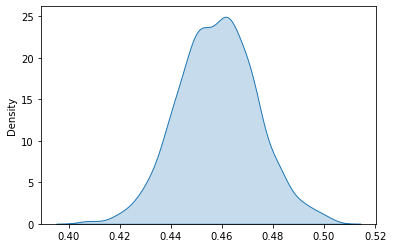

In [13]:

# Generate 1000 coin tosses
tosses = np.random.binomial(1, 0.5, size=1000)

# Estimate the heads probability
heads_prob = get_heads_prob(tosses)
# heads_prob = tosses.mean()

# Plot the distribution of heads probability
sns.kdeplot(heads_prob, shade=True, label="heads probabilty")
plt.show()

# The more you toss, the more you learn

Imagine you are a frequentist (just for a day), and you've been tasked with estimating the probability of tossing heads with a (possibly biased) coin, but without observing any tosses. What would you say? It's impossible, there is no data! Then, you are allowed to flip the coin once. You get tails. What do you say now? Well, if that's all your data, you'd say the heads probability is 0%.

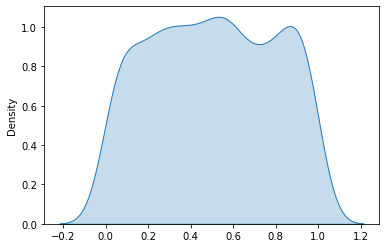

In [14]:
# Estimate and plot heads probability based on no data
heads_prob_nodata = get_heads_prob([])
sns.kdeplot(heads_prob_nodata, shade=True, label="no data")
plt.show()

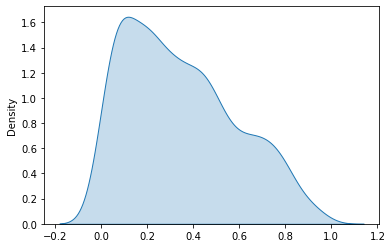

In [15]:
# Estimate and plot heads probability based on a single tails
heads_prob_onetails = get_heads_prob([0])
sns.kdeplot(heads_prob_onetails, shade=True, label="single tails")
plt.show()

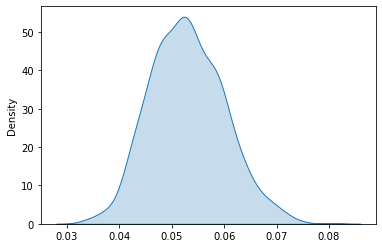

In [16]:
# Estimate and plot heads probability based on 1000 tosses with a biased coin
biased_tosses = np.random.binomial(1, 0.05, size=1000)
heads_prob_biased = get_heads_prob(biased_tosses)
sns.kdeplot(heads_prob_biased, shade=True, label="biased coin")
plt.show()

 With no data, each possible value of the heads probabilty is equally likely! That's the Bayesian way of saying 'we don't know'. Having seen a single tails, the model suspects that tails is more likely than heads, but since there is so little data, it is not very sure about it, so other values are possible, too. Having seen 1000 tosses, 5% of them heads, the model is certain: the heads probability is around 5%. You have just witnessed the Bayesian approach at its core: as more data come in, we update our belief about the parameter, and with more data we become more certain about our estimate!

# Hey, is this coin fair?

Now, let's get down to some serious stuff: would you like to play coin flipping against your friend? She is willing to play, as long as you use her special lucky coin. The tosses variable contains a list of 1000 results of tossing her coin. Will you play?

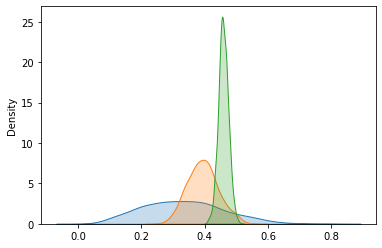

In [18]:
# Assign first 10 and 100 tosses to separate variables
tosses_first_10 = tosses[:10]
tosses_first_100 = tosses[:100]

# Get head probabilities for first 10, first 100, and all tossses
heads_prob_first_10 = get_heads_prob(tosses_first_10)
heads_prob_first_100 = get_heads_prob(tosses_first_100)
heads_prob_all = get_heads_prob(tosses)


# Plot density of head probability for each subset of tosses
sns.kdeplot(heads_prob_first_10, shade=True, label="first_10")
sns.kdeplot(heads_prob_first_100, shade=True, label="first_100")
sns.kdeplot(heads_prob_all, shade=True, label="all")
plt.show()